# 2002 AA29

## Initialize

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
from astroquery.jplhorizons import Horizons
from scipy.signal import find_peaks

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

In [2]:
AU_TO_KM = 1.495978707e8
EARTH_RADIUS_KM = 6371.0
DAYS_PER_JULIAN_YEAR = 365.25
KM3S2_TO_AU3D2 = (86400**2) / (AU_TO_KM**3)

# primary body (sun)
NAME_PRIMARY = 'Sun'
MU_PRIMARY = 1.32712440018e11
COLOR_PRIMARY = 'darkorange'

# secondary body (earth)
NAME_SECONDARY = 'Earth'
MU_SECONDARY = 3.986004418e5
COLOR_SECONDARY = 'dodgerblue'

MU = MU_SECONDARY / (MU_PRIMARY + MU_SECONDARY)

# particle (2002 AA29)
NAME_PARTICLE = '2002 AA$_{29}$'
COLOR_PARTICLE = 'lightseagreen'

# particle 2 (apophis)
NAME_PARTICLE2 = '99942 Apophis'
COLOR_PARTICLE2 = 'indianred'

# 2026 to 2750
EPOCH_START_JD = 2461041.5
EPOCH_END_JD = 2725476.5
DURATION_DAYS = EPOCH_END_JD - EPOCH_START_JD

# scale factor
K = 2 * np.pi / DAYS_PER_JULIAN_YEAR


In [3]:
def get_rotation_coords(vec_particle, vec_secondary):
    theta = np.arctan2(vec_secondary['y'], vec_secondary['x'])
    omega = (vec_secondary['x'] * vec_secondary['vy'] - vec_secondary['y'] * vec_secondary['vx']) / (vec_secondary['x']**2 + vec_secondary['y']**2)

    dx = vec_particle['x'] - vec_secondary['x']
    dy = vec_particle['y'] - vec_secondary['y']
    dz = vec_particle['z'] - vec_secondary['z']
    
    dvx = vec_particle['vx'] - vec_secondary['vx']
    dvy = vec_particle['vy'] - vec_secondary['vy']
    dvz = vec_particle['vz'] - vec_secondary['vz']
    
    x_rot = dx * np.cos(theta) + dy * np.sin(theta)
    y_rot = -dx * np.sin(theta) + dy * np.cos(theta)
    z_rot = dz
    
    vx_rot = (dvx * np.cos(theta) + dvy * np.sin(theta)) + (omega * y_rot)
    vy_rot = (-dvx * np.sin(theta) + dvy * np.cos(theta)) - (omega * x_rot)
    vz_rot = dvz
    
    return pd.DataFrame({
        'x': x_rot, 'y': y_rot, 'z': z_rot,
        'vx': vx_rot, 'vy': vy_rot, 'vz': vz_rot
    })

def get_jacobi_constant(vec_particle, vec_secondary):
    x, y, z = vec_particle['x'], vec_particle['y'], vec_particle['z']
    vx, vy, vz = vec_particle['vx'], vec_particle['vy'], vec_particle['vz']
    x_s, y_s, z_s = vec_secondary['x'], vec_secondary['y'], vec_secondary['z']
    
    r1 = np.sqrt(x**2 + y**2 + z**2)
    r2 = np.sqrt((x - x_s)**2 + (y - y_s)**2 + (z - z_s)**2)
    
    potential_term = (1 - MU) / r1 + MU / r2
    centrifugal_term = (x * vy - y * vx) / K
    velocity_term = (vx**2 + vy**2 + vz**2) / K**2

    cj = 2 * potential_term + 2 * centrifugal_term - velocity_term
    
    return cj

def get_iso_date(t_days):
    jd = np.array(t_days) + EPOCH_START_JD
    t = Time(jd, format='jd').iso[:10]
    return t

In [13]:
# Mercury6 data
col = ['time', 'long', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'a', 'e', 'i']

vec_earth = pd.read_csv('2002AA29/EARTH.aei', sep='\s+', skiprows=4, names=col)
vec_aa29 = pd.read_csv('2002AA29/2002AA29.aei', sep='\s+', skiprows=4, names=col)
vec_apophis = pd.read_csv('2002AA29/APOPHIS.aei', sep='\s+', skiprows=4, names=col)

x_earth, y_earth, z_earth = vec_earth['x'], vec_earth['y'], vec_earth['z']
x_icrf, y_icrf, z_icrf = vec_aa29['x'], vec_aa29['y'], vec_aa29['z']
x_icrf2, y_icrf2, z_icrf2 = vec_apophis['x'], vec_apophis['y'], vec_apophis['z']

vec_aa29_rot = get_rotation_coords(vec_aa29, vec_earth)
vec_apophis_rot = get_rotation_coords(vec_apophis, vec_earth)

x_rot, y_rot, z_rot = vec_aa29_rot['x'], vec_aa29_rot['y'], vec_aa29_rot['z']
x_rot2, y_rot2, z_rot2 = vec_apophis_rot['x'], vec_apophis_rot['y'], vec_apophis_rot['z']

In [5]:
# Horizons Data
duration_years = 100
stop_jd = EPOCH_START_JD + (duration_years * DAYS_PER_JULIAN_YEAR)

start_iso = Time(EPOCH_START_JD, format='jd').to_value('iso', subfmt='date')
stop_iso = Time(stop_jd, format='jd').to_value('iso', subfmt='date')

epochs = {
    'start': start_iso,
    'stop': stop_iso,
    'step': '200d'
}

obj_earth_hor = Horizons(id='3', location='@sun', epochs=epochs)
vec_earth_hor = obj_earth_hor.vectors()

obj_aa29_hor = Horizons(id='2002 AA29', location='@sun', epochs=epochs)
vec_aa29_hor = obj_aa29_hor.vectors()
vec_aa29_hor_rot = get_rotation_coords(vec_aa29_hor, vec_earth_hor)
x_rot_hor, y_rot_hor, z_rot_hor = vec_aa29_hor_rot['x'], vec_aa29_hor_rot['y'], vec_aa29_hor_rot['z']

/home/saika/miniconda3/envs/astro/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


## ICRF

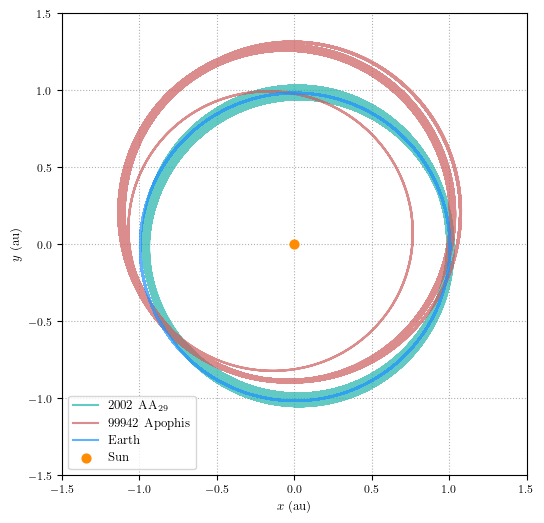

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(x_icrf, y_icrf, label=NAME_PARTICLE, color=COLOR_PARTICLE, alpha=0.7, zorder=2)
ax.plot(x_icrf2, y_icrf2, label=NAME_PARTICLE2, color=COLOR_PARTICLE2, alpha=0.7, zorder=2)
ax.plot(x_earth, y_earth, label=NAME_SECONDARY, color=COLOR_SECONDARY, alpha=0.7, zorder=3)
ax.scatter(0, 0, label=NAME_PRIMARY, color=COLOR_PRIMARY, s=40, zorder=2)

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('$x$ (au)')
ax.set_ylabel('$y$ (au)')
ax.legend()
ax.grid(True, linestyle=':')
ax.legend(loc='lower left')

fig.savefig('2002AA29_icrf.pdf', format='pdf', bbox_inches='tight')
plt.show()

## Earth-centric Rotational Coordinates

### Jacobi Constant

/home/saika/miniconda3/envs/astro/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 52669 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/saika/miniconda3/envs/astro/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


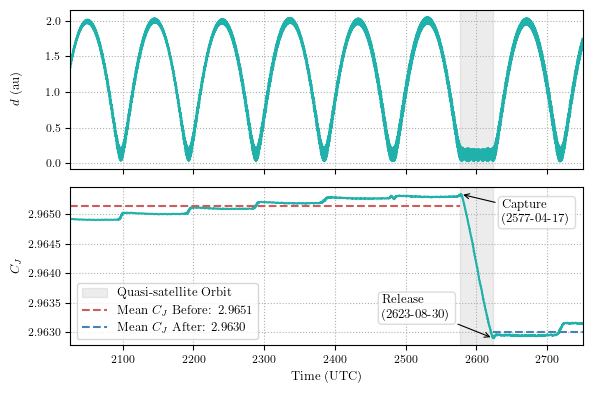

In [7]:
# Distance and Jacobi Const.
dist = np.sqrt(x_rot**2 + y_rot**2 + z_rot**2)
cj = get_jacobi_constant(vec_aa29, vec_earth)

# Capture and Release Point
idx_capture = np.argmax(cj)
idx_release = np.argmin(cj)

t_capture = vec_aa29['time'][idx_capture]
t_release = vec_aa29['time'][idx_release]
capture_duration = t_release - t_capture

mask_pre_capture  = vec_aa29['time'] < t_capture
mask_post_release = vec_aa29['time'] > t_release

# Cj before/after capture
cj_max = np.max(cj)
cj_min = np.min(cj)
cj_mean_pre  = np.mean(cj[mask_pre_capture])
cj_mean_post = np.mean(cj[mask_post_release])

# JD to Year
time_jd = vec_aa29['time'].values + EPOCH_START_JD
time_dt = Time(time_jd, format='jd').to_datetime()

dt_capture = time_dt[idx_capture]
dt_release = time_dt[idx_release]
dt_start = time_dt[0]
dt_end = time_dt[-1]

# Phase Angle
phase_rad = np.sin(np.arctan2(y_rot, x_rot+1))

# Plotting
span_style = dict(label='Quasi-satellite Orbit', color='gray', alpha=0.15, zorder=0)
annotate_style = dict(
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='black', lw=0.8),
    bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.3', edgecolor='lightgray'),
    fontsize=9, zorder=5
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

# Distance
ax1.plot(time_dt, dist, color=COLOR_PARTICLE)
ax1.axvspan(dt_capture, dt_release, **span_style)

ax1.set_ylabel('$d$ (au)')
ax1.grid(True, linestyle=':')

# Jacobi const.
ax2.plot(time_dt, cj, color=COLOR_PARTICLE)
ax2.axvspan(dt_capture, dt_release, **span_style)

ax2.hlines(cj_mean_pre, dt_start, dt_capture, colors='indianred', linestyles='--', label=f'Mean $C_J$ Before: {cj_mean_pre:.4f}')
ax2.hlines(cj_mean_post, dt_release, dt_end, colors='steelblue', linestyles='--', label=f'Mean $C_J$ After: {cj_mean_post:.4f}')

ax2.annotate(f'Capture\n({get_iso_date(t_capture)})', xy=(dt_capture, cj_max), xytext=(30, -20), **annotate_style)
ax2.annotate(f'Release\n({get_iso_date(t_release)})', xy=(dt_release, cj_min), xytext=(-80, 15), **annotate_style)

ax2.set_xlim(dt_start, dt_end)
ax2.set_xlabel('Time (UTC)')
ax2.set_ylabel('$C_J$')
ax2.legend(loc='lower left')
ax2.grid(True, linestyle=':')

fig.align_ylabels()

plt.tight_layout()

fig.savefig('2002AA29_jacobi.pdf', format='pdf', bbox_inches='tight')
plt.show()

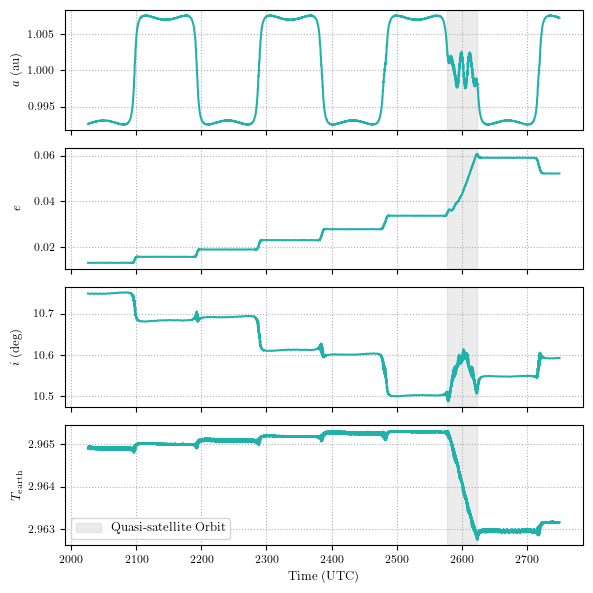

In [8]:
T_e = vec_earth['a'] / vec_aa29['a'] + 2 * np.sqrt((vec_aa29['a'] / vec_earth['a']) * (1 - vec_aa29['e']**2)) * np.cos(np.deg2rad(vec_aa29['i']))

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(6, 6), sharex=True)

ax1.plot(time_dt, vec_aa29['a'], color=COLOR_PARTICLE)
ax1.axvspan(dt_capture, dt_release, **span_style)

ax1.set_ylabel('$a$ (au)')
ax1.grid(True, linestyle=':')

ax2.plot(time_dt, vec_aa29['e'], color=COLOR_PARTICLE)
ax2.axvspan(dt_capture, dt_release, **span_style)

ax2.set_ylabel('$e$')
ax2.grid(True, linestyle=':')

ax3.plot(time_dt, vec_aa29['i'], color=COLOR_PARTICLE)
ax3.axvspan(dt_capture, dt_release, **span_style)

ax3.set_ylabel('$i$ (deg)')
ax3.grid(True, linestyle=':')

ax4.plot(time_dt, T_e, color=COLOR_PARTICLE)
ax4.axvspan(dt_capture, dt_release, **span_style)

ax4.set_xlabel('Time (UTC)')
ax4.set_ylabel('$T_\mathrm{earth}$')
ax4.grid(True, linestyle=':')
ax4.legend(loc='lower left')

fig.align_ylabels()
plt.tight_layout()

fig.savefig('2002AA29_tisserand.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [9]:
windows_yr = [
    (0, 100), (100, 200), (200, 300), 
    (300, 400), (400, 500), (500, 600)
]

peak_days = []

for start_yr, end_yr in windows_yr:
    mask = (vec_aa29['time'] >= start_yr * DAYS_PER_JULIAN_YEAR) & (vec_aa29['time'] <= end_yr * DAYS_PER_JULIAN_YEAR)
    window_dist = dist[mask]
    
    if not window_dist.empty:
        idx_max = window_dist.idxmax()
        peak_days.append(vec_aa29.loc[idx_max, 'time'])

peak_iso = get_iso_date(peak_days)
mean_period = np.mean(np.diff(peak_days) / DAYS_PER_JULIAN_YEAR)

print(f"Detected Peak Years: {peak_iso}")
print(f"Average Period: {mean_period:.4f} Years")

Detected Peak Years: ['2050-06-19 00:00:00.864' '2144-06-16 00:00:03.456'
 '2240-06-18 00:00:06.048' '2336-06-20 00:00:09.504'
 '2433-06-16 00:00:12.096' '2530-06-13 00:00:14.688']
Average Period: 95.9945 Years


/home/saika/miniconda3/envs/astro/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 6 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


### Relative Trajactory

/home/saika/miniconda3/envs/astro/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


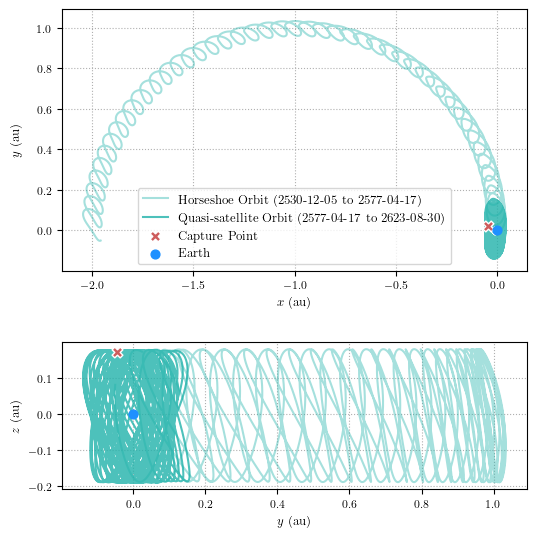

In [10]:
# Orbital Phase Analysis
t_start = t_capture - capture_duration
mask_before = (vec_aa29['time'] >= t_start) & (vec_aa29['time'] <= t_capture)
mask_after = (vec_aa29['time'] >= t_capture) & (vec_aa29['time'] <= t_release)

t_start_iso = get_iso_date(t_start)
t_capture_iso = get_iso_date(t_capture)
t_release_iso = get_iso_date(t_release)

x_capture = x_rot[idx_capture]
y_capture = y_rot[idx_capture]
z_capture = z_rot[idx_capture]

# Rotational Coordinates Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 7), gridspec_kw={'hspace': 0.05})

ax1.plot(x_rot[mask_before], y_rot[mask_before], label=f'Horseshoe Orbit ({t_start_iso} to {t_capture_iso})', color=COLOR_PARTICLE, alpha=0.4, zorder=2)
ax1.plot(x_rot[mask_after], y_rot[mask_after], label=f'Quasi-satellite Orbit ({t_capture_iso} to {t_release_iso})', color=COLOR_PARTICLE, alpha=0.8, zorder=3)
ax1.scatter(x_capture, y_capture, label='Capture Point', color='indianred', marker='X', s=60, zorder=4, edgecolors='white')
ax1.scatter(0, 0, label=NAME_SECONDARY, color=COLOR_SECONDARY, s=40, zorder=4)

ax1.set_aspect('equal')
ax1.set_xlabel('$x$ (au)')
ax1.set_ylabel('$y$ (au)')
ax1.legend()
ax1.grid(True, linestyle=':')

ax2.plot(y_rot[mask_before], z_rot[mask_before], color=COLOR_PARTICLE, alpha=0.4, zorder=2)
ax2.plot(y_rot[mask_after], z_rot[mask_after], color=COLOR_PARTICLE, alpha=0.8, zorder=3)
ax2.scatter(x_capture, z_capture, color='indianred', marker='X', s=60, zorder=4, edgecolors='white')
ax2.scatter(0, 0, color=COLOR_SECONDARY, s=40, zorder=4)

ax2.set_xlabel('$y$ (au)')
ax2.set_ylabel('$z$ (au)')
ax2.set_aspect('equal')
ax2.grid(True, linestyle=':')

fig.align_ylabels()
fig.savefig('2002AA29_rot.pdf', format='pdf', bbox_inches='tight')
plt.show()

## Horizons Data Comparison

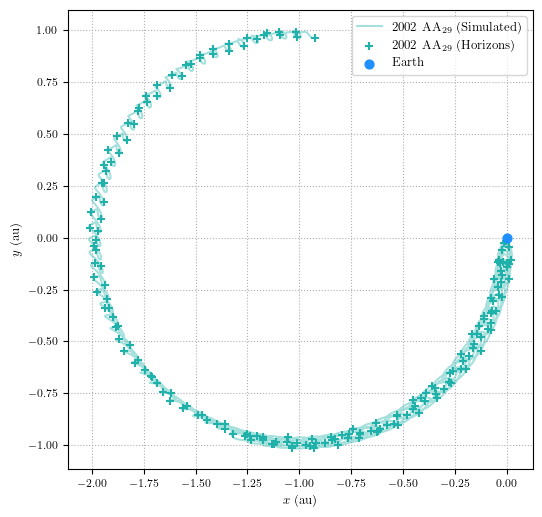

In [11]:
# Rotation Coordinates


mask_hor = (vec_aa29['time'] >= 0) & (vec_aa29['time'] <= 100 * DAYS_PER_JULIAN_YEAR)

# Horizons Rotational Coordinates Plotting
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(x_rot[mask_hor], y_rot[mask_hor], label=f"{NAME_PARTICLE} (Simulated)", color=COLOR_PARTICLE, alpha=0.4, zorder=2)
ax.scatter(x_rot_hor, y_rot_hor, label=f"{NAME_PARTICLE} (Horizons)", color=COLOR_PARTICLE, marker='+', s=30, zorder=3)

ax.scatter(0, 0, label=NAME_SECONDARY, color=COLOR_SECONDARY, s=40, zorder=3)

ax.set_aspect('equal')
ax.set_xlabel('$x$ (au)')
ax.set_ylabel('$y$ (au)')
ax.legend()
ax.grid(True, linestyle=':')

fig.savefig('2002AA29_hor.pdf', format='pdf', bbox_inches='tight')
plt.show()